# Plotting!!!!

Making plots on matplotlib so I can get the coordinates of the bedrock I need for constraints.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import ert
import os

First we must implement the code...

In [ ]:
header = 9
filename = r'C:\Users\sydne\git\erth370\erth370-w2026-sydpas\data\line04\Line04_DD-Grad-wTOPO_constraints.dat'
with open(filename, 'r') as f:
    lines = f.readlines()[header:]  # skip header lines

Create lists for each electrode!

In [14]:
Ax, Az = [], []
Bx, Bz = [], []
Mx, Mz = [], []
Nx, Nz = [], []
values = []

Now we make lists of all the points.

In [49]:
for line in lines:
    parts = line.strip().split()
    if len(parts) < 10:   # skip empty or incomplete lines
        continue
    parts = parts[1:]  # skip num of elec
    Ax.append(float(parts[0])); Az.append(float(parts[1]))
    Bx.append(float(parts[2])); Bz.append(float(parts[3]))
    Mx.append(float(parts[4])); Mz.append(float(parts[5]))
    Nx.append(float(parts[6])); Nz.append(float(parts[7]))
    values.append(float(parts[8]))

And we plot!!!

For x versus apparent resist:
- We can look for lateral changes and zones that are more resistive horizontally.
- Spikes = local anomalies.
- Clusters = consistant features.

For z (pseudo-depth) versus apparent resist:
- If deeper measurements have higher/lower resist.

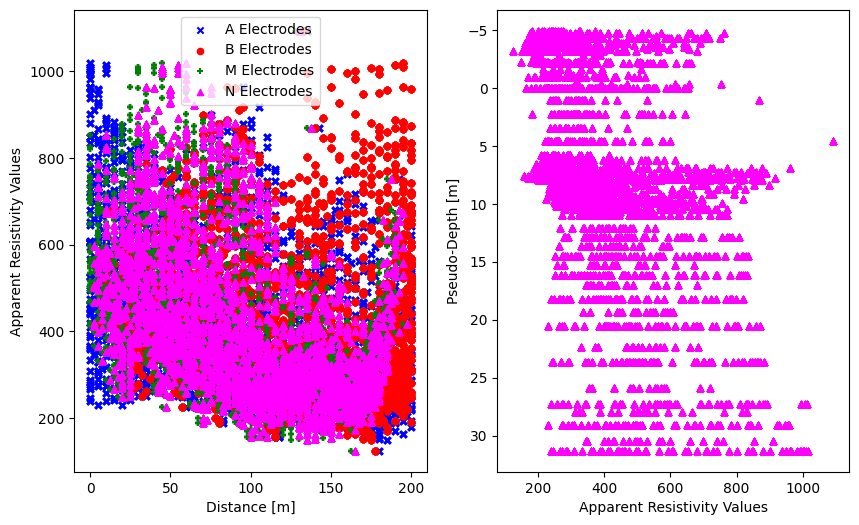

In [55]:
fig, (ax, ax1) = plt.subplots(figsize=(10, 6), nrows=1, ncols=2)

# first we plot x vs values to find zones that are more resistive horiz
A = ax.scatter(Ax, values, s=20, marker='x', color='blue', label='A Electrodes')
B = ax.scatter(Bx, values, s=20, marker='o', color='red', label='B Electrodes')
M = ax.scatter(Mx, values, s=20, marker='+', color='green', label='M Electrodes')
N = ax.scatter(Nx, values, s=20, marker='^', color='magenta', label='N Electrodes')
A_x_z = ax1.scatter(values, Az, s=20, marker='^', color='magenta', label='N Electrodes')

ax1.invert_yaxis()
ax.set_xlabel('Distance [m]')
ax.set_ylabel('Apparent Resistivity Values')
ax1.set_xlabel('Apparent Resistivity Values')
ax1.set_ylabel('Pseudo-Depth [m]')
ax.legend()
plt.show()